In [1]:
import h5py
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SQRT_2PI = np.sqrt(2 * np.pi)

# -- Jackknife: generalized to arrays of shape (N_jk, ...), axis=0 -----------
def Jackknife(datalist):
    arr = np.asarray(datalist, dtype=float)
    N = arr.shape[0]
    theta_bar = arr.mean(axis=0)
    sigma_sq = ((N - 1) / N) * np.sum((arr - theta_bar) ** 2, axis=0)
    return theta_bar, np.sqrt(sigma_sq)

# -- Compact error formatter ---------------------------------------------
def fmt_err(mean, err):
    if err <= 0:
        return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        ms = mean / 10**exp; es = err / 10**exp
        pl = int(math.floor(math.log10(abs(es))))
        nd = max(0, -(pl - 1))
        return f"{ms:.{nd}f}({int(round(es*10**nd))})e{exp}"
    else:
        pl = int(math.floor(math.log10(abs(err))))
        nd = max(0, -(pl - 1))
        return f"{mean:.{nd}f}({int(round(err*10**nd))})"

# -- H5 loader -------------------------------------------------------------
def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        for key in f["jackknife_samples"].keys():
            fitted_params[key] = f["jackknife_samples"][key][:]
        chi2_dof_list = f["chi2_dof"][:]
    return fitted_params, chi2_dof_list

# -- LaTeX / Markdown parameter table ---------------------------------------
def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax):
    res = {k: fmt_err(*Jackknife(v)) for k, v in fitted_params.items()}
    chi2_str = fmt_err(*Jackknife(chi2_dof_list))

    re_params   = ['a_re', 'c_re', 'd_re', 'k1_re', 'k2_re', 'f']
    im_params   = ['a_im', 'c_im', 'd_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'f']

    vals_re   = ", ".join(res[p] for p in re_params   if p in res)
    vals_im   = ", ".join(res[p] for p in im_params   if p in res)
    vals_a12b = ", ".join(res[p] for p in a12b_params if p in res)

    eq_re   = r"$a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$"
    eq_im   = r"$a\,\mathrm{Pb}\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$"
    eq_a12b = r"$-a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$"

    names_re   = "$\\{" + ", ".join(re_params)   + "\\}$"
    names_im   = "$\\{" + ", ".join(im_params)   + "\\}$"
    names_a12b = "$\\{" + ", ".join(a12b_params) + "\\}$"

    md  = "\n### GaussianPb\_Expb Simultaneous Fit (common $f$)\n"
    md += f"$P_L={PL}$,&nbsp; $b_{{\\min}}\\ge{bmin}a$,&nbsp; $\\eta\\in[{etamin},{etamax}]$\n\n"
    md += f"$\\chi^2/\\text{{DoF}} = {chi2_str}$ (Global)\n\n"
    md += "| Amplitude | Model Expression | Params | Fitted Values |\n"
    md += "| :--- | :--- | :--- | :--- |\n"
    md += f"| $\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}$ | {eq_re} | {names_re} | $[{vals_re}]$ |\n"
    md += f"| $\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}}$ | {eq_im} | {names_im} | $[{vals_im}]$ |\n"
    md += f"| $\\tilde{{A}}_{{12B}}^{{\\text{{Re}}}}$ | {eq_a12b} | {names_a12b} | $[{vals_a12b}]$ |\n"

    try:
        display(Markdown(md))
    except Exception:
        print(md)

# -- Main FT + integration table + 6-panel plot -----------------------------
def re_tilde(a, c, bpart, x):
    return a[:, None] * bpart[:, None] * (1.0/np.sqrt(2*c[:, None])) * np.exp(-x[None, :]**2 / (4*c[:, None]))

def im_evals_fn(a, c, bpart, x):
    # im_evals(x) := i * ImA2B~(x)  (real-valued; matches reference row-2 convention)
    return -a[:, None] * bpart[:, None] * x[None, :] * np.exp(-x[None, :]**2 / (4*c[:, None])) / (2*c[:, None])**1.5

def A_at_zero(a, c, bpart):
    return a * bpart

def plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL,
                                      bminfit, etamin, etamax, num_points=200):
    print_latex_table(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)

    x_vals = np.linspace(-1, 1, num_points)

    MassN    = 0.6228
    lata     = 0.11403
    massterm = MassN * (197.0 * 0.001 / lata)

    b = np.sqrt(b2)   # fixed Lorentz-invariant |b| (b^2 = bL^2 + bT^2 held fixed)

    # -- Jackknife parameter arrays, shape (N_jk,) ---------------------------
    a_re  = np.array(fitted_params['a_re'])
    c_re  = np.array(fitted_params['c_re'])
    d_re  = np.array(fitted_params['d_re'])

    a_im  = np.array(fitted_params['a_im'])
    c_im  = np.array(fitted_params['c_im'])
    d_im  = np.array(fitted_params['d_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])   # sign flip already in the model
    c_reA12B =  np.array(fitted_params['c_reA12B'])
    d_reA12B =  np.array(fitted_params['d_reA12B'])


    bpart_re    = np.exp(-d_re * b)
    bpart_im    = np.exp(-d_im * b)
    bpart_a12b  = np.exp(-d_reA12B * b)

    # =========================================================================
    # Integration table (all rows fully analytic; only the finite x-ranges
    # need a trivial 1D numerical integration of the closed-form curve)
    # =========================================================================
    print("\nEvaluating analytical Fourier transforms across Jackknife samples...")

    # {-inf, +inf}: exact via Parseval, Integral Atilde(x) dx = sqrt(2*pi)*A(lambda=0)
    int_inf_re   = SQRT_2PI * A_at_zero(a_re,      c_re,      bpart_re)
    int_inf_im   = np.zeros_like(a_im)                        # odd -> A_im(0) = 0
    int_inf_a12b = SQRT_2PI * A_at_zero(a_reA12B,  c_reA12B,  bpart_a12b)

    x_fine = np.linspace(-1, 1, 1000)
    re_xf   = re_tilde(a_re,      c_re,      bpart_re,   x_fine)   # (N_jk, 1000)
    im_xf   = im_evals_fn(a_im,   c_im,      bpart_im,   x_fine)
    a12b_xf = re_tilde(a_reA12B,  c_reA12B,  bpart_a12b, x_fine)

    m11  = (x_fine >= -1) & (x_fine <= 1)
    mm10 = (x_fine >= -1) & (x_fine <= 0)
    m01  = (x_fine >= 0)  & (x_fine <= 1)

    int_11_re    = np.trapz(re_xf[:,  m11],  x=x_fine[m11],  axis=1)
    int_m10_re   = np.trapz(re_xf[:,  mm10], x=x_fine[mm10], axis=1)
    int_01_re    = np.trapz(re_xf[:,  m01],  x=x_fine[m01],  axis=1)

    int_11_im    = np.trapz(im_xf[:,  m11],  x=x_fine[m11],  axis=1)
    int_m10_im   = np.trapz(im_xf[:,  mm10], x=x_fine[mm10], axis=1)
    int_01_im    = np.trapz(im_xf[:,  m01],  x=x_fine[m01],  axis=1)

    int_11_a12b  = np.trapz(a12b_xf[:, m11],  x=x_fine[m11],  axis=1)
    int_m10_a12b = np.trapz(a12b_xf[:, mm10], x=x_fine[mm10], axis=1)
    int_01_a12b  = np.trapz(a12b_xf[:, m01],  x=x_fine[m01],  axis=1)

    res_re  = [int_inf_re,   int_11_re,   int_m10_re,   int_01_re]
    res_im  = [int_inf_im,   int_11_im,   int_m10_im,   int_01_im]
    res_f1  = [2*(res_re[i] - res_im[i]) for i in range(4)]
    res_f1T = [-2*int_inf_a12b, -2*int_11_a12b, -2*int_m10_a12b, -2*int_01_a12b]
    res_siv = [massterm * res_f1T[i] / res_f1[i] for i in range(4)]

    def format_jk(data):
        m, e = Jackknife(data)
        return fmt_err(m, e)

    row1 = [format_jk(d) for d in res_re]
    row2 = [format_jk(d) for d in res_im]
    row3 = [format_jk(d) for d in res_f1]
    row4 = [format_jk(d) for d in res_f1T]
    row5 = [format_jk(d) for d in res_siv]

    md_int  = "\n### Analytical Fourier Transform Integration Table\n\n"
    md_int += "| Integral | $\\{-\\infty,\\infty\\}$ | $\\{-1,1\\}$ | $\\{-1,0\\}$ | $\\{0,1\\}$ |\n"
    md_int += "| :--- | :--- | :--- | :--- | :--- |\n"
    md_int += (f"| $\\int dx\\,\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}$ "
               f"| {row1[0]} | {row1[1]} | {row1[2]} | {row1[3]} |\n")
    md_int += (f"| $\\int dx\\,(i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ "
               f"| {row2[0]} | {row2[1]} | {row2[2]} | {row2[3]} |\n")
    md_int += (f"| $\\tilde{{f}}_1^{{(0)}}=2\\int dx\\,"
               f"(\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}"
               f"-i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ "
               f"| {row3[0]} | {row3[1]} | {row3[2]} | {row3[3]} |\n")
    md_int += (f"| $\\tilde{{f}}_{{1T}}^{{\\perp(1)}}=-2\\int dx\\,"
               f"\\tilde{{A}}_{{12B}}$ "
               f"| {row4[0]} | {row4[1]} | {row4[2]} | {row4[3]} |\n")
    md_int += (f"| $m_N\\dfrac{{\\tilde{{f}}_{{1T}}^{{\\perp(1)}}}}"
               f"{{\\tilde{{f}}_1^{{(0)}}}}$ "
               f"| {row5[0]} | {row5[1]} | {row5[2]} | {row5[3]} |\n")

    try:
        display(Markdown(md_int))
    except Exception:
        print(md_int)

    # =========================================================================
    # Plotting -- fully vectorized analytic evaluation over x_vals
    # =========================================================================
    re_v   = re_tilde(a_re,      c_re,      bpart_re,   x_vals)   # (N_jk, num_points)
    im_v   = im_evals_fn(a_im,   c_im,      bpart_im,   x_vals)
    a12b_v = re_tilde(a_reA12B,  c_reA12B,  bpart_a12b, x_vals)

    full_v = 2 * (re_v - im_v)
    f1T_v  = -2 * a12b_v
    siv_v  = massterm * f1T_v / full_v
    xsiv_v = x_vals[None, :] * siv_v

    re_mean,     re_err     = Jackknife(re_v)
    im_mean,     im_err     = Jackknife(im_v)
    full_mean,   full_err   = Jackknife(full_v)
    reA12B_mean, reA12B_err = Jackknife(f1T_v)
    SivShift_mean,  SivShift_err  = Jackknife(siv_v)
    xSivShift_mean, xSivShift_err = Jackknife(xsiv_v)

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean-re_err, re_mean+re_err, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$'); ax1.set_ylabel('$\\tilde{A}_{2B}^{Re}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean-im_err, im_mean+im_err, color='red', alpha=0.3)
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$'); ax2.set_ylabel('$i\\tilde{A}_{2B}^{Im}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean-full_err, full_mean+full_err, color='green', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax3.set_xlabel('$x$'); ax3.set_ylabel('$\\tilde{f}_{1}^{(0)}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    ax4.plot(x_vals, reA12B_mean, color='blue')
    ax4.fill_between(x_vals, reA12B_mean-reA12B_err, reA12B_mean+reA12B_err,
                     color='blue', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax4.set_xlabel('$x$'); ax4.set_ylabel('$\\tilde{f}_{1}^{\\perp(1)}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    mask = x_vals >= 0

    ax5.plot(x_vals[mask], SivShift_mean[mask], color='blue')
    ax5.fill_between(x_vals[mask],
                     SivShift_mean[mask]-SivShift_err[mask],
                     SivShift_mean[mask]+SivShift_err[mask],
                     color='blue', alpha=0.3)
    ax5.set_title(f'$\\langle k_{{y}}\\rangle_{{TU}}$ (GeV) ($P_L$={PL}, $b^2$={b2})')
    ax5.set_xlabel('$x$'); ax5.set_ylabel('$\\langle k_{y}\\rangle_{TU}$ (GeV)')
    ax5.grid(True, linestyle='--', alpha=0.6)

    ax6.plot(x_vals[mask], xSivShift_mean[mask], color='blue')
    ax6.fill_between(x_vals[mask],
                     xSivShift_mean[mask]-xSivShift_err[mask],
                     xSivShift_mean[mask]+xSivShift_err[mask],
                     color='blue', alpha=0.3)
    ax6.set_title(f'$x\\langle k_{{y}}\\rangle_{{TU}}$ (GeV) ($P_L$={PL}, $b^2$={b2})')
    ax6.set_xlabel('$x$'); ax6.set_ylabel('$x\\langle k_{y}\\rangle_{TU}$ (GeV)')
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = (f"SimulFitCovMatrix-A12B-A2B-FT-{param_keys_str}"
                 f"__bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.pdf")
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()
    return



### GaussianPb\_Expb Simultaneous Fit (common $f$)
$P_L=-1$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 2.39(12)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_re, c_re, d_re, k1_re, k2_re, f\}$ | $[3.69(11), 0.169(16), 0.5463(66), 11.35(18), -31.93(99), 0.4307(44)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $a\,\mathrm{Pb}\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_im, c_im, d_im, f\}$ | $[0.05(12), 0.57(17), 0.252(87), 0.4307(44)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $-a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_reA12B, c_reA12B, d_reA12B, f\}$ | $[1.185(89), 0.0038(69), 0.592(22), 0.4307(44)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 1.798(45) | 1.644(53) | 0.821(26) | 0.821(26) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | 3(28402)e-20 | 0.008(14) | -0.008(14) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 3.596(89) | 3.29(11) | 1.626(58) | 1.657(61) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 1.006(56) | 1.006(56) | 0.498(29) | 0.498(29) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.301(16) | 0.329(19) | 0.330(21) | 0.324(20) |


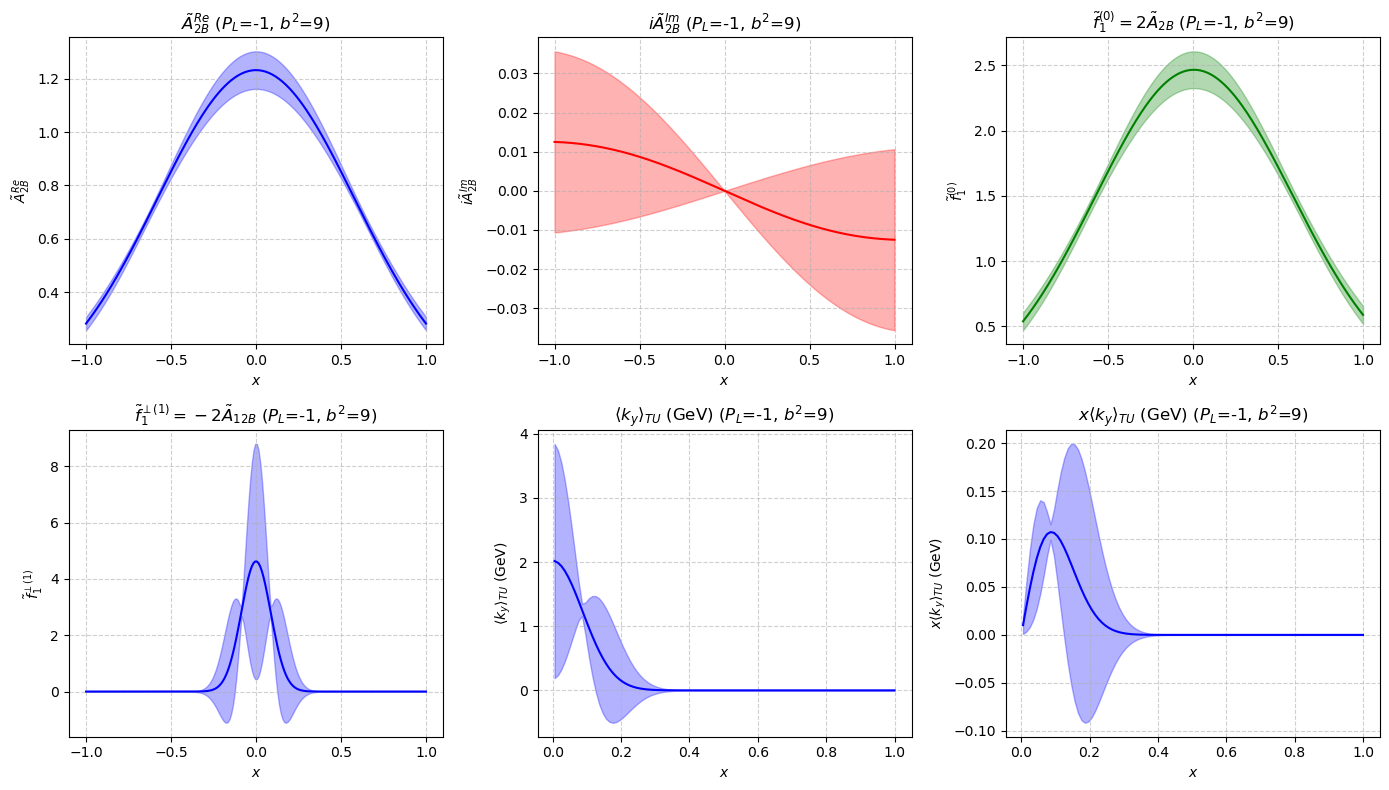

In [2]:
b2      = 9
PL      = -1
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_GaussianPb_Expb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### GaussianPb\_Expb Simultaneous Fit (common $f$)
$P_L=-1$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 2.39(12)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_re, c_re, d_re, k1_re, k2_re, f\}$ | $[3.69(11), 0.169(16), 0.5463(66), 11.35(18), -31.93(99), 0.4307(44)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $a\,\mathrm{Pb}\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_im, c_im, d_im, f\}$ | $[0.05(12), 0.57(17), 0.252(87), 0.4307(44)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $-a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_reA12B, c_reA12B, d_reA12B, f\}$ | $[1.185(89), 0.0038(69), 0.592(22), 0.4307(44)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 0.1945(75) | 0.1778(77) | 0.0888(38) | 0.0888(38) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -3(12422)e-20 | 0.0028(40) | -0.0028(40) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 0.389(15) | 0.356(15) | 0.172(11) | 0.183(11) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.090(11) | 0.090(11) | 0.0448(55) | 0.0448(55) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.250(30) | 0.273(33) | 0.280(37) | 0.263(34) |


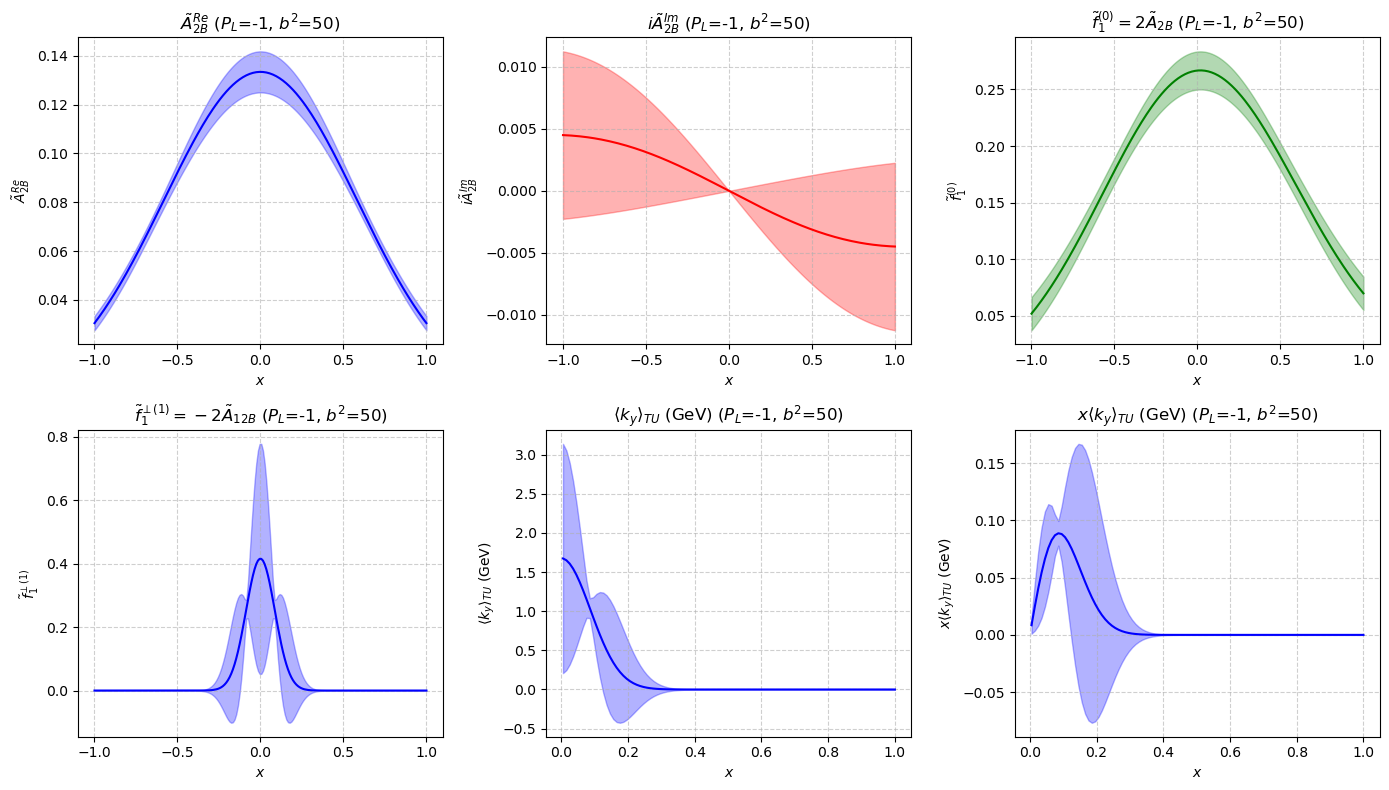

In [3]:
b2      = 50
PL      = -1
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_GaussianPb_Expb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### GaussianPb\_Expb Simultaneous Fit (common $f$)
$P_L=-2$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 2.01(11)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_re, c_re, d_re, k1_re, k2_re, f\}$ | $[4.54(30), 0.0546(79), 0.608(15), 10.40(24), -26.7(13), 0.4721(99)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $a\,\mathrm{Pb}\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_im, c_im, d_im, f\}$ | $[0.243(15), 0.367(51), 0.218(15), 0.4721(99)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $-a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_reA12B, c_reA12B, d_reA12B, f\}$ | $[1.127(88), 0.0021(21), 0.602(25), 0.4721(99)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 1.84(11) | 1.83(11) | 0.915(53) | 0.915(53) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -3(33800)e-19 | 0.073(20) | -0.073(20) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 3.68(21) | 3.67(21) | 1.68(11) | 1.98(11) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.928(66) | 0.928(66) | 0.458(33) | 0.458(33) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.271(17) | 0.272(17) | 0.293(20) | 0.250(17) |


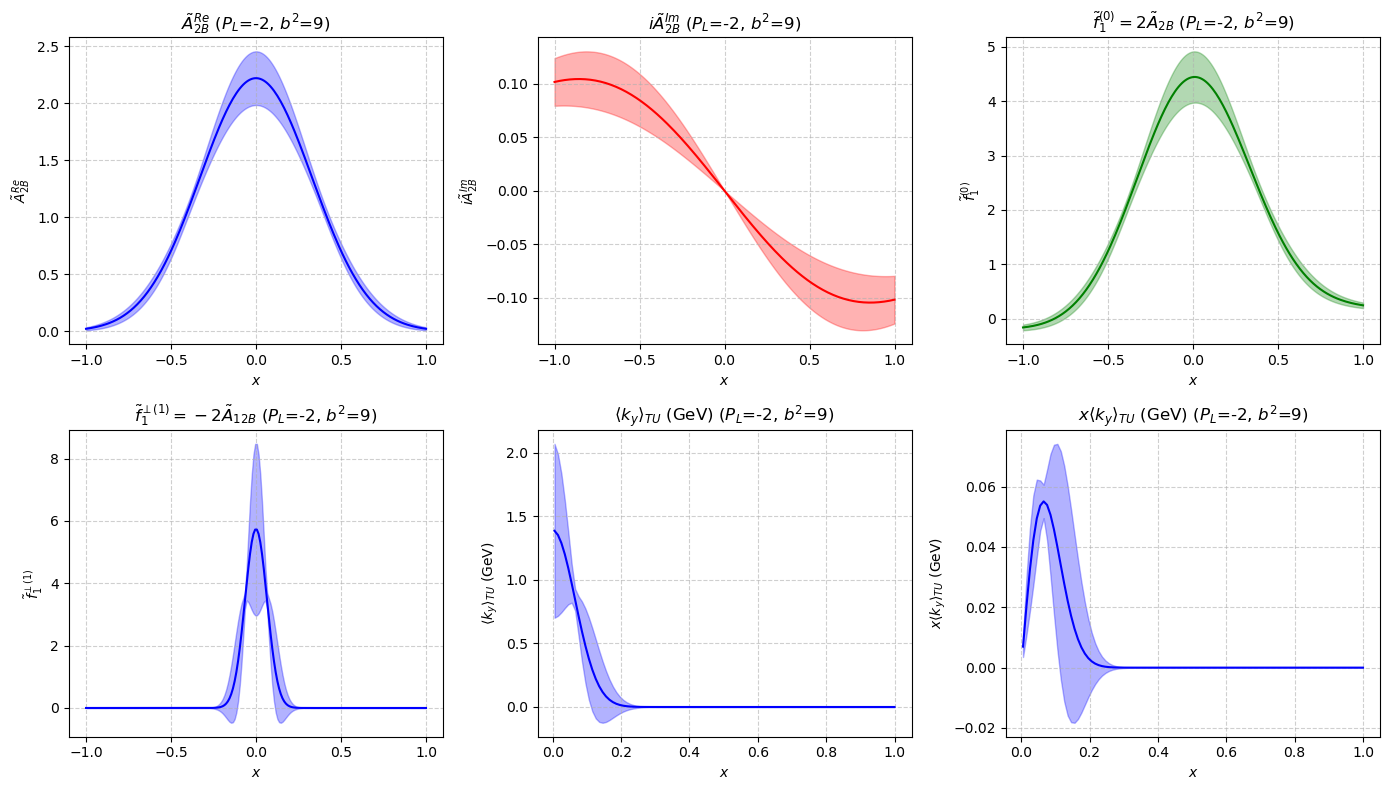

In [4]:
b2      = 9
PL      = -2
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_GaussianPb_Expb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### GaussianPb\_Expb Simultaneous Fit (common $f$)
$P_L=-3$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 0.945(76)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_re, c_re, d_re, k1_re, k2_re, f\}$ | $[5.28(53), 0.046(16), 0.687(35), 11.35(28), -32.2(15), 0.513(20)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $a\,\mathrm{Pb}\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_im, c_im, d_im, f\}$ | $[0.25982(16), 0.3016(15), 0.20020(19), 0.513(20)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $-a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_reA12B, c_reA12B, d_reA12B, f\}$ | $[0.56(10), 0.0016(15), 0.478(47), 0.513(20)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 1.69(20) | 1.68(20) | 0.840(98) | 0.840(98) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | 2(3837)e-18 | 0.10338(71) | -0.10338(71) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 3.37(39) | 3.37(40) | 1.47(20) | 1.89(20) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.665(97) | 0.665(97) | 0.328(48) | 0.328(48) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.212(28) | 0.212(28) | 0.239(33) | 0.187(24) |


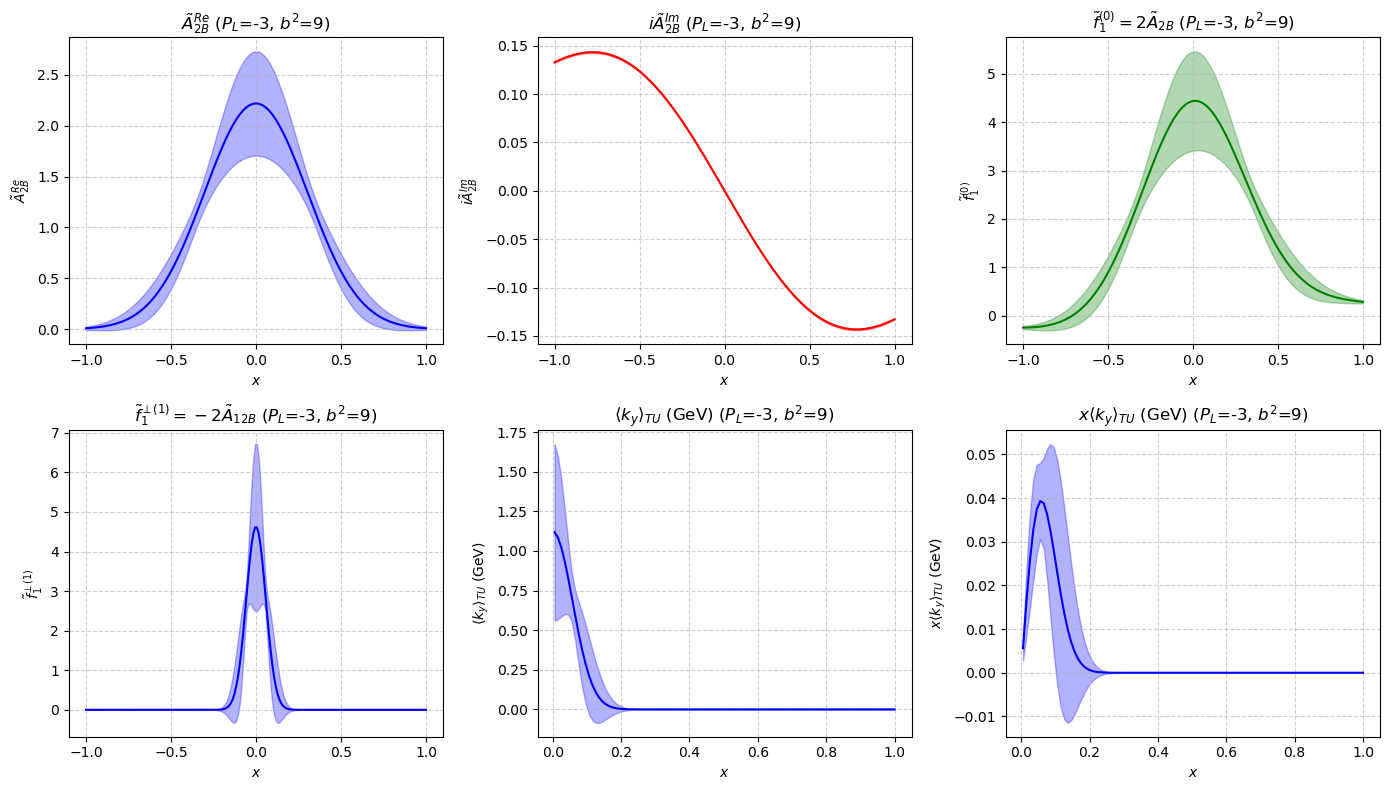

In [5]:
b2      = 9
PL      = -3
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_GaussianPb_Expb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### GaussianPb\_Expb Simultaneous Fit (common $f$)
$P_L=-4$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 0.453(52)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_re, c_re, d_re, k1_re, k2_re, f\}$ | $[6.07(31), 0.019(19), 0.655(64), 12.06(38), -36.0(22), 0.577(35)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $a\,\mathrm{Pb}\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_im, c_im, d_im, f\}$ | $[0.260000002(17), 0.29999997(28), 0.199999998(20), 0.577(35)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $-a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_reA12B, c_reA12B, d_reA12B, f\}$ | $[0.439(98), 0.0043(27), 0.427(54), 0.577(35)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 2.14(42) | 2.14(42) | 1.06(21) | 1.06(21) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -2(3878)e-18 | 0.10415427(13) | -0.10415427(13) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 4.27(84) | 4.27(84) | 1.92(42) | 2.33(42) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.61(15) | 0.61(15) | 0.303(74) | 0.303(74) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.154(38) | 0.154(38) | 0.170(44) | 0.140(34) |


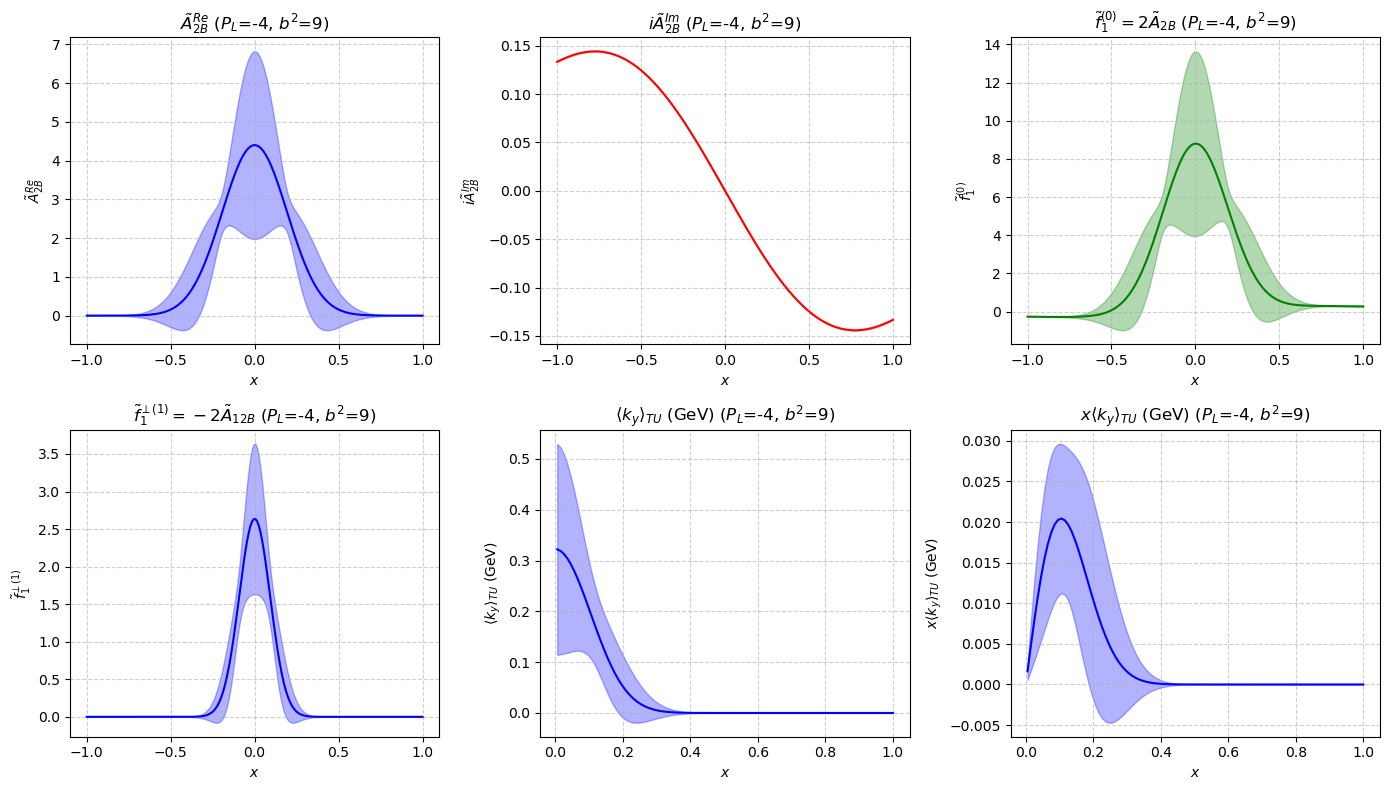

In [6]:
b2      = 9
PL      = -4
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_GaussianPb_Expb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### GaussianPb\_Expb Simultaneous Fit (common $f$)
$P_L=-4$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 0.453(52)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_re, c_re, d_re, k1_re, k2_re, f\}$ | $[6.07(31), 0.019(19), 0.655(64), 12.06(38), -36.0(22), 0.577(35)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $a\,\mathrm{Pb}\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_im, c_im, d_im, f\}$ | $[0.260000002(17), 0.29999997(28), 0.199999998(20), 0.577(35)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $-a\,\exp(-c\,\mathrm{Pb}^2-d\lvert b\rvert)$ | $\{a_reA12B, c_reA12B, d_reA12B, f\}$ | $[0.439(98), 0.0043(27), 0.427(54), 0.577(35)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 0.30(12) | 0.30(12) | 0.149(58) | 0.149(58) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -7(19874)e-19 | 0.057161074(72) | -0.057161074(72) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 0.60(23) | 0.60(23) | 0.18(12) | 0.41(12) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.170(59) | 0.170(59) | 0.084(30) | 0.084(30) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.30(12) | 0.30(12) | 0.49(28) | 0.219(75) |


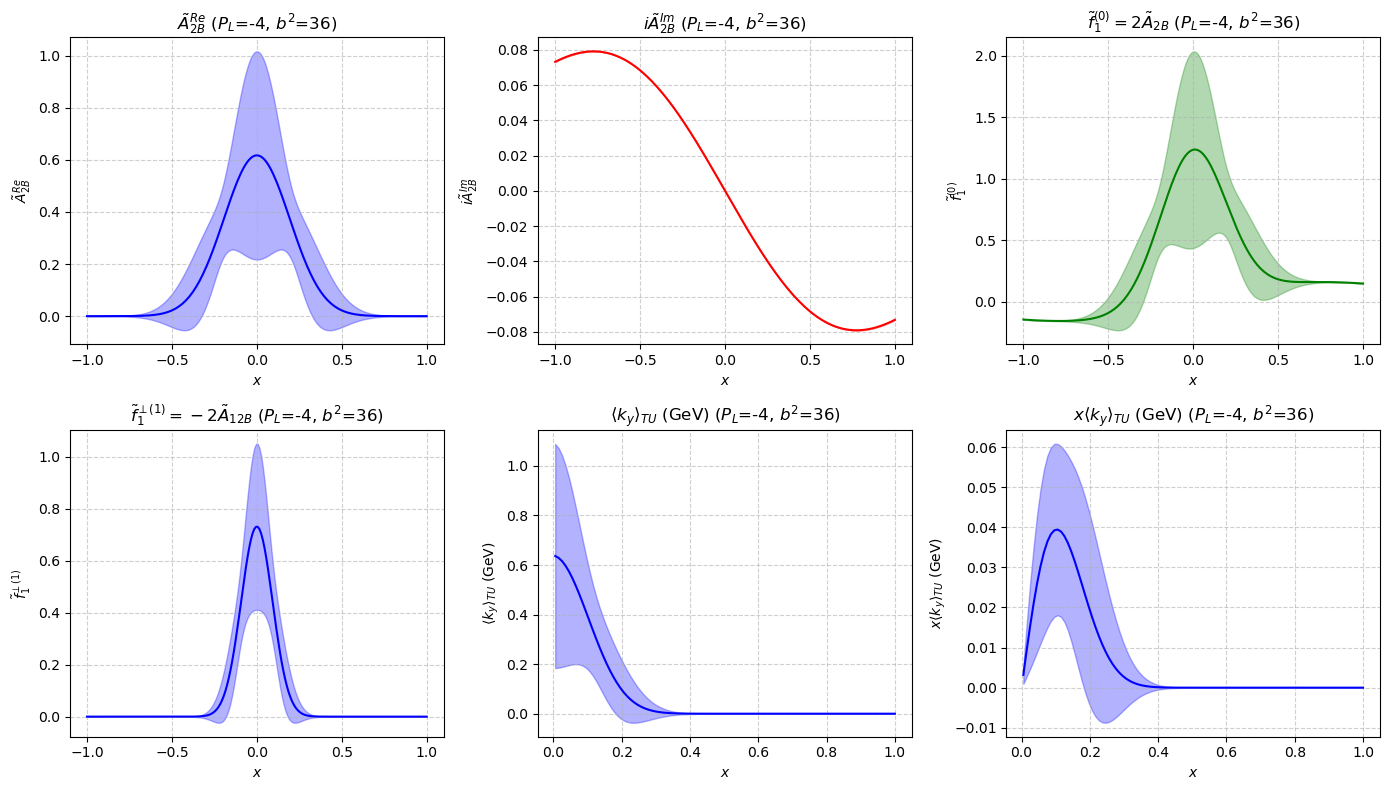

In [7]:
b2      = 36
PL      = -4
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_GaussianPb_Expb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)
